I0000 00:00:1782907703.446787   30665 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782907704.206961   30665 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782907706.276925   30665 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


--- STARTING DATA LOAD ---
Found 4 database files.
Loading 'Like_and_Subscribe.db' as class: 'Like_and_Subscribe'...
  -> Loaded 3093 samples.
Loading 'Idle.db' as class: 'Idle'...
  -> Loaded 3750 samples.
Loading 'Drinking_Coffee.db' as class: 'Drinking_Coffee'...
  -> Loaded 3466 samples.
Loading 'Jumping_Jacks.db' as class: 'Jumping_Jacks'...
  -> Loaded 2912 samples.
Label Mapping: {0: np.str_('Drinking_Coffee'), 1: np.str_('Idle'), 2: np.str_('Jumping_Jacks'), 3: np.str_('Like_and_Subscribe')}

Total Windows: 158
Train Windows:   118
Val Windows:     20
Test Windows:    20

--- GENERATING DISTRIBUTION PLOT ---


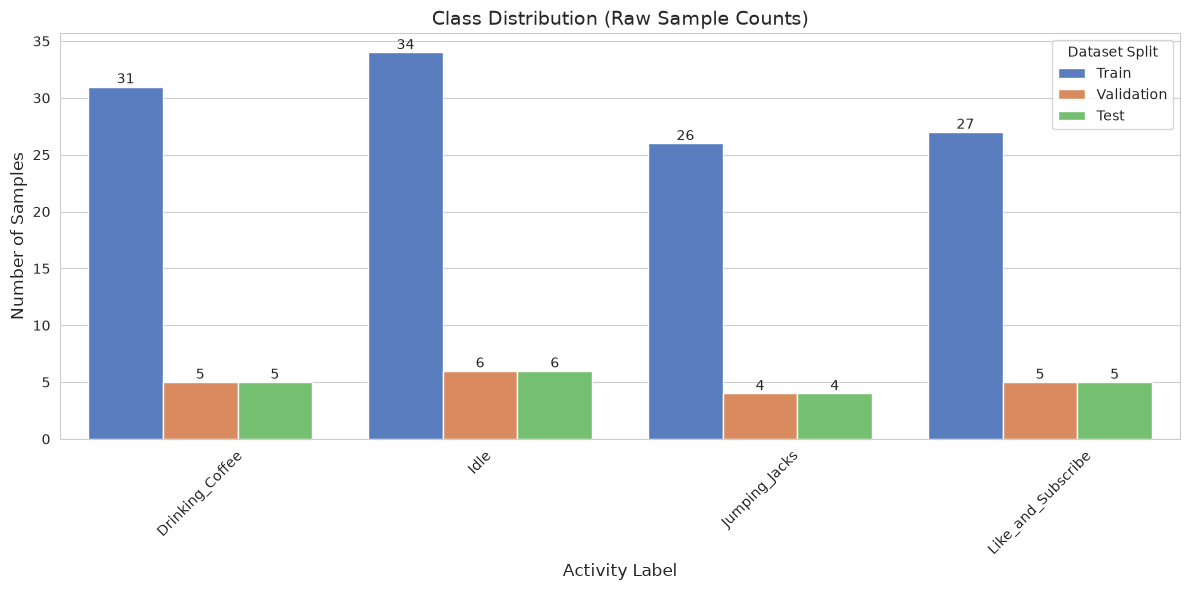


Normalization Stats:
Means: [-7583.82644068  8580.08949153 -3201.61265537]
Standard deviation:  [14335.97151627  6452.27892926  7948.75031525]


In [ ]:
import os
import glob
import sqlite3
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense
from keras.callbacks import EarlyStopping
from dataclasses import dataclass

# --- CONFIGURATION ---
DATA_FOLDER = "MHOOP_dataset"
OUTPUT_FOLDER = "MHOOP_outputs"
WINDOW_SIZE = 150         # 3 seconds @ 50Hz
STEP_SIZE = 75            # 50% overlap
EPOCHS = 200
BATCH_SIZE = 32


TABLE_NAME = "accelerometer_data"
ORDER_TABLE_BY = "local_timestamp" 
SENSOR_DATA_COLUMNS = ["x", "y", "z"]
DATA_DIMENSIONS = len(SENSOR_DATA_COLUMNS)
LABLE_COLUMN = "lable"

KERNEL_SIZE = 3


COLORS = ["r", "g", "b"]

# Create the output folder if it doesn't exist
if not os.path.exists(OUTPUT_FOLDER):
	os.makedirs(OUTPUT_FOLDER)
	print(f"Created output directory: {OUTPUT_FOLDER}")

# ==========================================
# 1. DATA LOADING
# ==========================================
def load_and_merge_data(folder_path: str) -> pd.DataFrame:
	all_data: list[pd.DataFrame] = []
	db_files: list[str] = glob.glob(os.path.join(folder_path, "*.db"))
	
	if not db_files:
		print("No .db files found! Make sure your files are in the 'datasets' folder.")
		return pd.DataFrame()

	print(f"Found {len(db_files)} database files.")

	for db_file in db_files:
		filename: str = os.path.basename(db_file)
		label: str = os.path.splitext(filename)[0]
		
		print(f"Loading '{filename}' as class: '{label}'...")
		
		try:
			with sqlite3.connect(db_file) as conn:
				df: pd.DataFrame = pd.read_sql_query(f"SELECT {", ".join(SENSOR_DATA_COLUMNS)} FROM {TABLE_NAME} ORDER BY {ORDER_TABLE_BY}", conn)

			#Labelling the data
			df[LABLE_COLUMN] = label
			all_data.append(df)
			print(f"  -> Loaded {len(df)} samples.")
		except Exception as e:
			print(f"  -> Error loading {db_file}: {e}")

	if not all_data:
		return pd.DataFrame()

	return pd.concat(all_data, ignore_index=True)

# Load the data
print("--- STARTING DATA LOAD ---")
data: pd.DataFrame = load_and_merge_data(DATA_FOLDER)

# Array for containing windows
# A window is a timeframe, which is analized to determin the current action  
window_list_type = np.ndarray[np.ndarray[float]]

# Array for containing the corresponding lables for the windows
# Each window is catogarized into a lable
lable_list_type = np.ndarray[str]

# Similar in function to lable_list_type
# A lable is a string, but the model cannot output a string
# Therefore the lables are converted into catagories
# e.g lables: "egg", "bacon", "ham" -> catagories [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]
catagory_list_type = np.ndarray[np.ndarray[float]]


# Similar in function to catagory_list_type
# e.g catagories [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0] -> encoded 0, 1, 2
catagory_list_indecies_type = np.ndarray[int]


class DataList:
	def __init__(self, windows_train_list: window_list_type, lables_train_list: lable_list_type, windows_val_list: window_list_type, lables_val_list: lable_list_type, windows_test_list: window_list_type, lables_test_list: lable_list_type):
		
		#Storing training data
		#3D array list[][WINDOW_SIZE][3]
		self.windows_train_raw : window_list_type = windows_train_list
		self.windows_val_raw   : window_list_type = windows_val_list
		self.windows_test_raw  : window_list_type = windows_test_list
		
		#Format: list of label strings
		self.lables_train  : lable_list_type  = lables_train_list
		self.lables_val    : lable_list_type  = lables_val_list
		self.lables_test   : lable_list_type  = lables_test_list




		# Encode Labels
		self.label_encoder = LabelEncoder()
		# Fit on all labels to ensure we know all classes
		self.label_encoder.fit(self.get_all_labels())

		self.classes: np.array = self.label_encoder.classes_
		self.num_classes = len(self.classes)
		print("Label Mapping:", dict(zip(range(self.num_classes), self.classes)))


		# Convert to One-Hot Encoding 
		self.catagories_train : catagory_list_type = to_categorical(self.label_encoder.transform(self.lables_train))
		self.catagories_val   : catagory_list_type = to_categorical(self.label_encoder.transform(self.lables_val))
		self.catagories_test  : catagory_list_type = to_categorical(self.label_encoder.transform(self.lables_test))



		self.catagories_train_indicies : catagory_list_indecies_type = np.argmax(self.catagories_train, axis = 1)
		self.catagories_val_indicies   : catagory_list_indecies_type = np.argmax(self.catagories_val,   axis = 1)
		self.catagories_test_indicies  : catagory_list_indecies_type = np.argmax(self.catagories_test,  axis = 1)


		# Calculating the mean and standard deviation
		# To calculate the mean and deviation, the windows are irrelevant. Therefor the training data is flatend into an array of data points
		windows_train_flat: np.ndarray[np.ndarray[float]] = self.windows_train_raw.reshape(-1, DATA_DIMENSIONS)
		self.mean: np.ndarray[float] = np.mean(windows_train_flat, axis=0)
		self.standard_deviation: np.ndarray[float] = np.std(windows_train_flat, axis=0)

		self.windows_train_normalized : window_list_type = (self.windows_train_raw - self.mean) / self.standard_deviation
		self.windows_val_normalized   : window_list_type = (self.windows_val_raw   - self.mean) / self.standard_deviation
		self.windows_test_normalized  : window_list_type = (self.windows_test_raw  - self.mean) / self.standard_deviation




	def get_all_labels(self):
		return np.concatenate([self.lables_train, self.lables_val, self.lables_test])

	def total_windows(self) -> int:
		return len(self.windows_train_raw) + len(self.windows_val_raw) + len(self.windows_test_raw)




# ==========================================
# 2. PREPROCESSING & SPLITTING
# ==========================================
def create_windows_from_array(data_array, label: str, window_size: int, step_size: int) -> tuple[list[list], list[str]]:
	windows: list[list] = []
	labels: list[str] = []
	# Loop over the array to create windows
	for i in range(0, len(data_array) - window_size + 1, step_size):
		window = data_array[i : i + window_size]
		windows.append(window)
		labels.append(label)
	return windows, labels

def robust_time_split(df: pd.DataFrame, window_size: int, step_size: int, val_ratio: float = 0.15, test_ratio: float = 0.15):
	
	windows_train_list : list[list[list[float]]] = []
	windows_val_list   : list[list[list[float]]] = []
	windows_test_list  : list[list[list[float]]] = []
	lables_train_list  : list[str]               = []
	lables_val_list    : list[str]               = []
	lables_test_list   : list[str]               = []

	# Process each lable separately by splitting the merged data into groups by the lables
	for label, group in df.groupby(LABLE_COLUMN):
		
		sensor_data : list[list[float]] = group[SENSOR_DATA_COLUMNS].values
		total_len   : int = len(sensor_data)

		# Calculate split indices based on time
		# Train ends where Val begins
		train_end_idx: int = int(total_len * (1 - val_ratio - test_ratio))
		# Val ends where Test begins
		val_end_idx: int = int(total_len * (1 - test_ratio))
		
		# Split raw data by time
		train_segment : list[list[float]] = sensor_data[:train_end_idx]
		val_segment   : list[list[float]] = sensor_data[train_end_idx:val_end_idx]
		test_segment  : list[list[float]] = sensor_data[val_end_idx:]
		
		# Create windows for each segment
		w_train, l_train = create_windows_from_array(train_segment, label, window_size, step_size)
		w_val,   l_val   = create_windows_from_array(val_segment,   label, window_size, step_size)
		w_test,  l_test  = create_windows_from_array(test_segment,  label, window_size, step_size)
		
		windows_train_list.extend(w_train)
		lables_train_list.extend(l_train)
		windows_val_list.extend(w_val)
		lables_val_list.extend(l_val)
		windows_test_list.extend(w_test)
		lables_test_list.extend(l_test)

	return DataList(np.array(windows_train_list), np.array(lables_train_list), 
			np.array(windows_val_list), np.array(lables_val_list),
			np.array(windows_test_list), np.array(lables_test_list))

if data.empty:
	print("No data loaded. Please check your .db files.")
	exit()




#TODO: Comment
# Perform the Time-Based Split
data_list: DataList = robust_time_split(
	data, WINDOW_SIZE, STEP_SIZE, val_ratio=0.15, test_ratio=0.15
)

print(f"\nTotal Windows: {data_list.total_windows()}")
print(f"Train Windows:   {len(data_list.windows_train_raw)}")
print(f"Val Windows:     {len(data_list.windows_val_raw)}")
print(f"Test Windows:    {len(data_list.windows_test_raw)}")




# Plot Raw Counts
def plot_class_distribution(data_list: DataList) -> None:


	plot_data = []
	for split_name, indices in [("Train", data_list.catagories_train_indicies), ("Validation", data_list.catagories_val_indicies), ("Test", data_list.catagories_test_indicies)]:
		
		# Getting the amounts of windows per catgory
		counts = pd.Series(indices).value_counts().sort_index()
		for class_idx in range(data_list.num_classes):
			count = counts.get(class_idx, 0)
			plot_data.append({
				"Class": data_list.classes[class_idx],
				"Split": split_name,
				"Count": count
			})
			
	df_plot = pd.DataFrame(plot_data)

	plt.figure(figsize=(12, 6))
	sns.set_style("whitegrid")
	ax = sns.barplot(data=df_plot, x="Class", y="Count", hue="Split", palette="muted")
	for container in ax.containers:
		ax.bar_label(container, fontsize=10)
	
	plt.title("Class Distribution (Raw Sample Counts)", fontsize=14)
	plt.ylabel("Number of Samples", fontsize=12)
	plt.xlabel("Activity Label", fontsize=12)
	plt.xticks(rotation=45)
	plt.legend(title="Dataset Split")
	plt.tight_layout()
	plt.show()

print("\n--- GENERATING DISTRIBUTION PLOT ---")
plot_class_distribution(data_list)


print(f"\nNormalization Stats:")
print(f"Means: {data_list.mean}")
print(f"Standard deviation:  {data_list.standard_deviation}")




--- PLOTTING AVERAGE WAVEFORMS ---


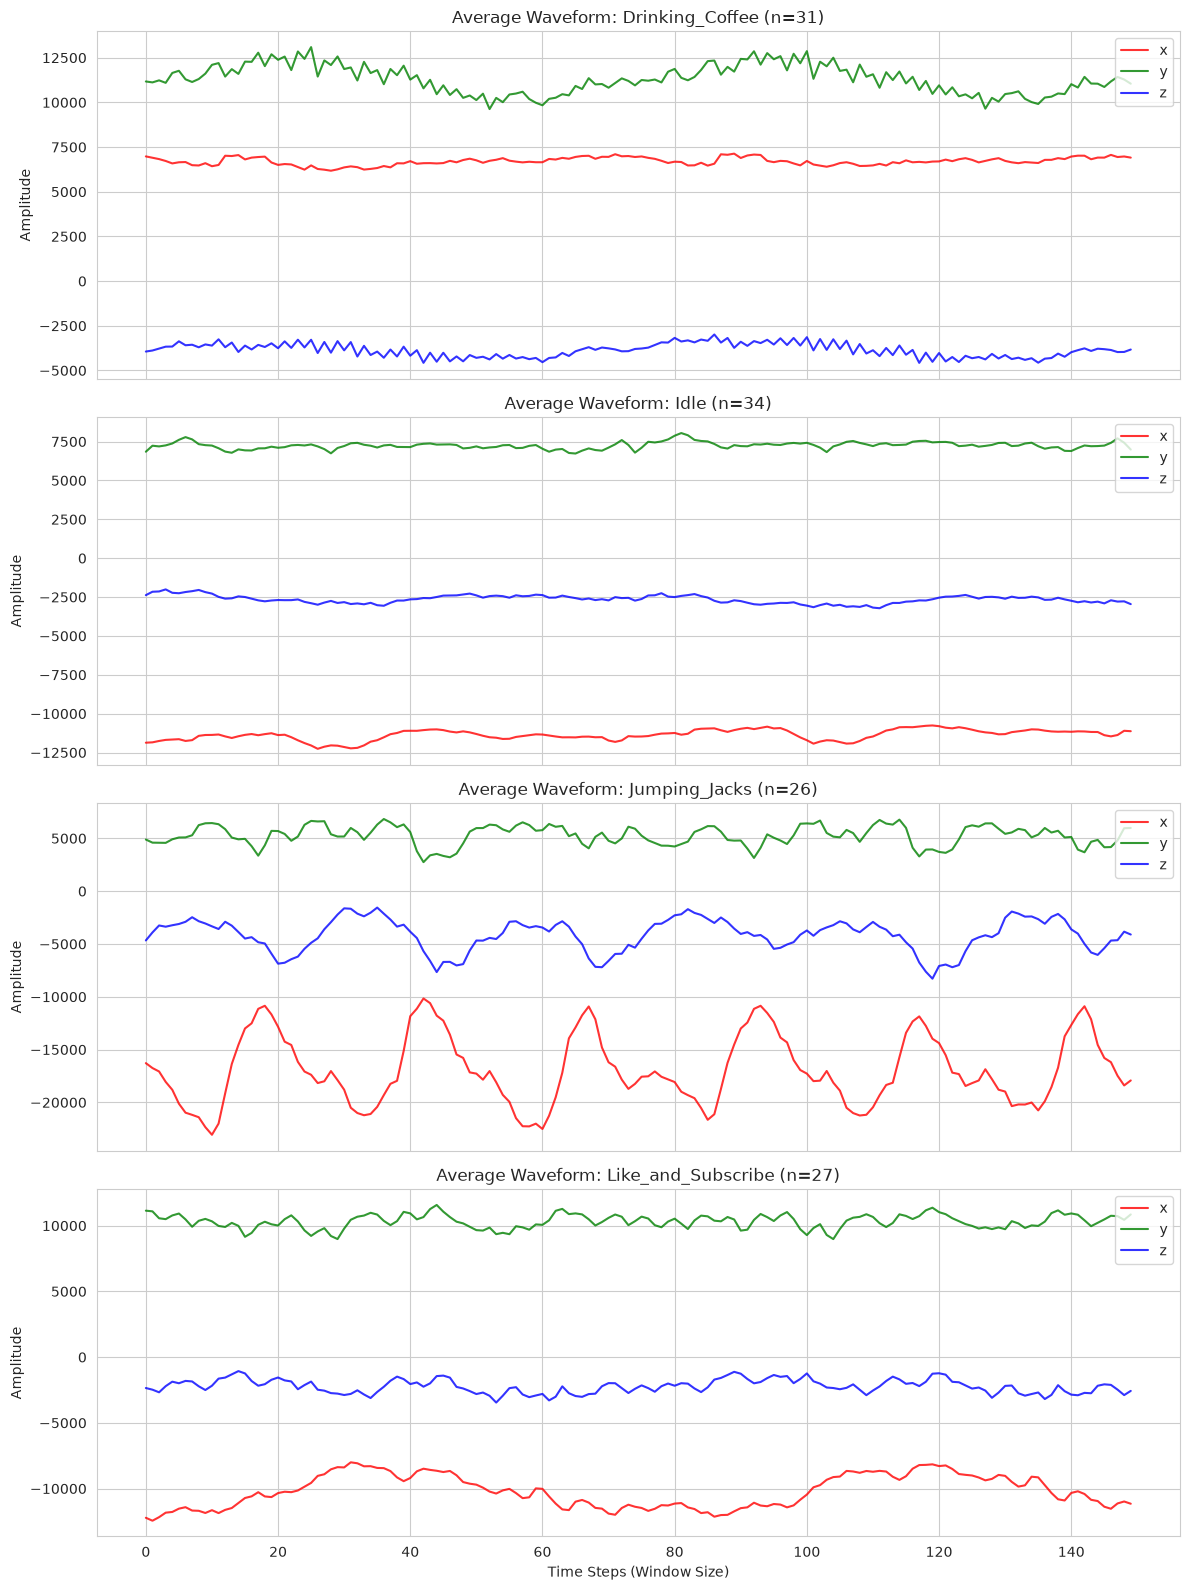

In [4]:
# ==========================================
# 4. PLOT AVERAGE WAVEFORMS PER CLASS
# ==========================================
def plot_average_waveforms(data_list: DataList) -> None:
	fig, axes = plt.subplots(data_list.num_classes, 1, figsize=(12, 4 * data_list.num_classes), sharex=True)
	
	if data_list.num_classes == 1: axes = [axes]

	time_steps = np.arange(data_list.windows_train_raw.shape[1])

	for i, class_name in enumerate(data_list.classes):
		# Filter all windows belonging to this class
		class_indices = np.where(data_list.catagories_train_indicies == i)[0]
		class_windows : window_list_type = data_list.windows_train_raw[class_indices]
		
		# Calculate the mean across all windows for this class (axis 0)
		# Result shape: (WINDOW_SIZE, 3)
		mean_waveform = np.mean(class_windows, axis=0)
		
		# Plot X, Y, Z
		ax = axes[i]
		for j, label in enumerate(SENSOR_DATA_COLUMNS):
			ax.plot(time_steps, mean_waveform[:, j], label=label, color=COLORS[j % len(COLORS)], alpha=0.8)

		
		ax.set_title(f"Average Waveform: {class_name} (n={len(class_indices)})")
		ax.set_ylabel("Amplitude")
		ax.legend(loc="upper right")
		ax.grid(True)

	plt.xlabel("Time Steps (Window Size)")
	plt.tight_layout()
	plt.show()

print("\n--- PLOTTING AVERAGE WAVEFORMS ---")
plot_average_waveforms(data_list)


--- TRAINING MODEL ---
Epoch 1/200


/home/finja/Documents/Diplomarbeit/EdgeAI/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1782758192.485432   49306 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.0847 - loss: 1.4181 - val_accuracy: 0.3000 - val_loss: 1.3404
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2458 - loss: 1.3637 - val_accuracy: 0.7500 - val_loss: 1.3058
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6186 - loss: 1.3135 - val_accuracy: 0.7500 - val_loss: 1.2742
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6525 - loss: 1.2723 - val_accuracy: 0.4500 - val_loss: 1.2427
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6525 - loss: 1.2267 - val_accuracy: 0.6000 - val_loss: 1.2114
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6441 - loss: 1.1886 - val_accuracy: 0.5500 - val_loss: 1.1828
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6271 - loss: 1.1511 - val_accuracy: 0.5500 - val_loss: 1.1548
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6186 - loss: 1.1131 - val_accuracy: 0.4500 - val_loss: 1.1256
Epoc

Original model saved to: MHOOP_outputs/model.h5

--- PLOTTING TRAINING CURVES ---


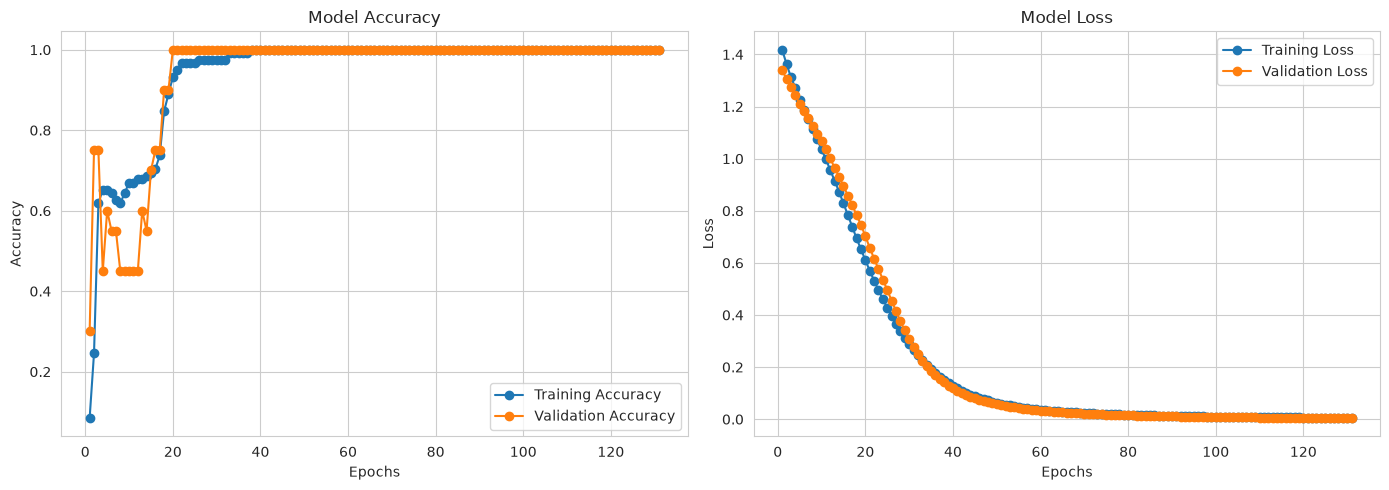


--- EVALUATION ON TEST SET ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
                    precision    recall  f1-score   support

   Drinking_Coffee       1.00      1.00      1.00         5
              Idle       1.00      1.00      1.00         6
     Jumping_Jacks       1.00      1.00      1.00         4
Like_and_Subscribe       1.00      1.00      1.00         5

          accuracy                           1.00        20
         macro avg       1.00      1.00      1.00        20
      weighted avg       1.00      1.00      1.00        20


--- PLOTTING CONFUSION MATRIX ---


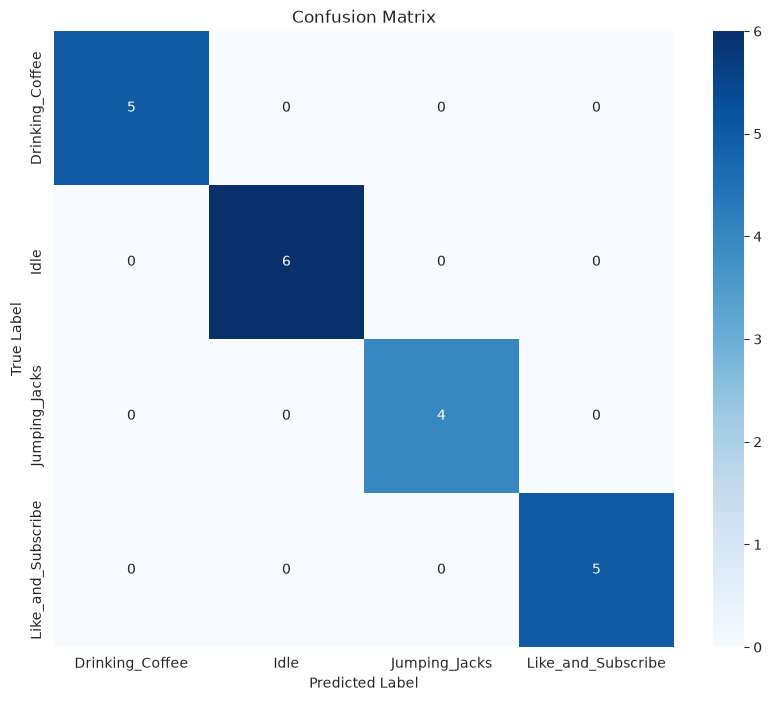

In [ ]:
# ==========================================
# 5. MODEL TRAINING (1D CNN)
# ==========================================


# Defining the model using different layers
# The first layer is the input layer and the last is the output
# kernel_size specifies how many values each kernel/nodes has. If we use X, Y, Z kernel_size must be 3
model = Sequential([
    Conv1D(filters = 16, kernel_size = KERNEL_SIZE, activation = 'relu', input_shape = (WINDOW_SIZE, DATA_DIMENSIONS)),
    MaxPooling1D(pool_size = 2),
    Conv1D(filters = 32, kernel_size = KERNEL_SIZE, activation = 'relu'),
    GlobalAveragePooling1D(),
    Dense(data_list.num_classes, activation = 'softmax')
])



model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Condition for stopping training
early_stopping = EarlyStopping(
    monitor='val_loss',  # Watch the validation loss
    min_delta=0.001,
    patience=10,         # Stop if it doesn't improve for 10 epochs
    restore_best_weights=True # Go back to the best model found
)

# Training the model
print("\n--- TRAINING MODEL ---")
history = model.fit(
    data_list.windows_train_normalized, data_list.catagories_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(data_list.windows_val_normalized, data_list.catagories_val),
    callbacks=[early_stopping],
    verbose=1
)

# SAVE ORIGINAL H5 MODEL
h5_path = os.path.join(OUTPUT_FOLDER, "model.h5")
model.save(h5_path)
print(f"Original model saved to: {h5_path}")

# ==========================================
# 6. PLOT TRAINING HISTORY
# ==========================================
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("\n--- PLOTTING TRAINING CURVES ---")
plot_training_history(history)

# ==========================================
# 7. EVALUATION
# ==========================================
print("\n--- EVALUATION ON TEST SET ---")
y_pred = model.predict(data_list.windows_test_normalized)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(data_list.lables_test, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=data_list.class_names))

# ==========================================
# 8. PLOT CONFUSION MATRIX
# ==========================================
def plot_confusion_matrix(y_true, y_pred, classes):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

print("\n--- PLOTTING CONFUSION MATRIX ---")
plot_confusion_matrix(y_true_classes, y_pred_classes, target_names=data_list.class_names)

In [4]:
# ==========================================
# 9. EXPORT & SIZE COMPARISON
# ==========================================
print("\n--- EXPORTING MODELS & COMPARING SIZES ---")

# Define paths
float_model_path = os.path.join(OUTPUT_FOLDER, "model_float32.tflite")
quant_model_path = os.path.join(OUTPUT_FOLDER, "model_quantized.tflite")

# Export Float32 Model (Non-Quantized)
converter_float = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float_model = converter_float.convert()

with open(float_model_path, "wb") as f:
    f.write(tflite_float_model)

# Export Int8 Model (Quantized)
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

converter_quant = tf.lite.TFLiteConverter.from_keras_model(model)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
converter_quant.representative_dataset = representative_data_gen
converter_quant.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_quant.inference_input_type = tf.int8
converter_quant.inference_output_type = tf.int8

tflite_quant_model = converter_quant.convert()

with open(quant_model_path, "wb") as f:
    f.write(tflite_quant_model)

# Calculate and Print Sizes
h5_size = os.path.getsize(h5_path)
float_size = os.path.getsize(float_model_path)
quant_size = os.path.getsize(quant_model_path)
reduction_h5_to_float = (1 - (float_size / h5_size)) * 100
reduction_h5_to_int = (1 - (quant_size / h5_size)) * 100
reduction_float_to_int = (1 - (quant_size / float_size)) * 100

print(f"\nModel Size Comparison:")
print(f"  H5 Model:   {h5_size / 1024:.2f} KB")
print(f"  Float32 Model:   {float_size / 1024:.2f} KB")
print(f"  Quantized Model: {quant_size / 1024:.2f} KB")
print(f"  Reduction (TFlite Convert): {reduction_h5_to_float:.2f}%")
print(f"  Reduction (TFlite Convert + quantisation): {reduction_h5_to_int:.2f}%")
print(f"  Reduction (quantisation): {reduction_float_to_int:.2f}%")

# ============================================
# 10. Generate C++ Header for Validation Data
# ============================================

print("\n--- GENERATING C++ HEADER (validation_data.h) ---")

num_samples = 5
indices = np.random.choice(len(X_test), num_samples)
samples_raw = X_test_raw[indices]
true_labels = y_test[indices]

cpp_content = f"""
#ifndef VALIDATION_DATA_H
#define VALIDATION_DATA_H

// Auto-generated validation data
// Class Map: {dict(zip(range(num_classes), class_names))}

const int num_validation_samples = {num_samples};

// Raw Input Data (Before Normalization)
const int16_t validation_samples[{num_samples}][{WINDOW_SIZE}][3] = {{
"""

for sample in samples_raw:
    cpp_content += "    {\n"
    for row in sample:
        cpp_content += f"        {{ {int(row[0])}, {int(row[1])}, {int(row[2])} }},\n"
    cpp_content += "    },\n"

cpp_content += "};\n\n"
cpp_content += f"// Expected Classes (Indices): {np.argmax(true_labels, axis=1).tolist()}\n"
cpp_content += "#endif // VALIDATION_DATA_H\n"

header_path = os.path.join(OUTPUT_FOLDER, "validation_data.h")
with open(header_path, "w") as f:
    f.write(cpp_content)

print("Saved 'validation_data.h'")
print("Done!")


--- EXPORTING MODELS & COMPARING SIZES ---
INFO:tensorflow:Assets written to: /tmp/tmprjd6wsr_/assets


INFO:tensorflow:Assets written to: /tmp/tmprjd6wsr_/assets


Saved artifact at '/tmp/tmprjd6wsr_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134562925729872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925728720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925729488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925731408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925731600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925728144: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1782758204.073509   49306 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782758204.073524   49306 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782758204.073766   49306 reader.cc:83] Reading SavedModel from: /tmp/tmprjd6wsr_
I0000 00:00:1782758204.074177   49306 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782758204.074183   49306 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmprjd6wsr_
I0000 00:00:1782758204.077620   49306 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782758204.078286   49306 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782758204.097688   49306 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmprjd6wsr_
I0000 00:00:1782758204.104544   49306 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 30783 microseconds.
I0000 00:00:1782758204.135341   49306

INFO:tensorflow:Assets written to: /tmp/tmp4c6ybk76/assets


INFO:tensorflow:Assets written to: /tmp/tmp4c6ybk76/assets


Saved artifact at '/tmp/tmp4c6ybk76'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134562925729872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925728720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925729488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925731408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925731600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134562925728144: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/finja/Documents/Diplomarbeit/EdgeAI/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782758204.531373   49306 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782758204.531395   49306 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782758204.531609   49306 reader.cc:83] Reading SavedModel from: /tmp/tmp4c6ybk76
I0000 00:00:1782758204.532206   49306 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782758204.532216   49306 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp4c6ybk76
I0000 00:00:1782758204.536021   49306 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782758204.557321   49306 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp4c6ybk76
I0000 00:00:1782758204.565478   49306 loader.cc:471] Save


Model Size Comparison:
  H5 Model:   53.67 KB
  Float32 Model:   12.08 KB
  Quantized Model: 8.59 KB
  Reduction (TFlite Convert): 77.50%
  Reduction (TFlite Convert + quantisation): 83.99%
  Reduction (quantisation): 28.85%

--- GENERATING C++ HEADER (validation_data.h) ---
Saved 'validation_data.h'
Done!


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1782758204.707812   49306 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
